# Sentiment Analysis using NLP

## Importing Libraries

In [1]:
import spacy
import nltk
import en_core_web_sm
import re
import pandas as pd
import random


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Datasets/train.csv",names=['sentiment','id','date','query','person','feedback'],encoding='latin1')

In [4]:
df.head()

,sentiment,id,date,query,person,feedback
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df.drop(['id','date','query','person'],axis=1,inplace=True)

In [6]:
df.shape

(1600000, 2)

In [7]:
df['sentiment'].unique()

array([0, 4])

In [8]:
import numpy as np

In [9]:
np.unique(df['sentiment'],return_counts=True)

(array([0, 4]), array([800000, 800000]))

## Splitting

In [29]:
x=df.iloc[:,1].values
y=df["sentiment"].values

In [30]:
print(x)
print(y)

["@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
 "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"
 '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds'
 ... 'Are you ready for your MoJo Makeover? Ask me for details '
 'Happy 38th Birthday to my boo of alll time!!! Tupac Amaru Shakur '
 'happy #charitytuesday @theNSPCC @SparksCharity @SpeakingUpH4H ']
[0 0 0 ... 4 4 4]


In [32]:
from sklearn.model_selection import train_test_split
x,_,y,_=train_test_split(x,y,test_size=0.98,random_state=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [33]:
x_train.shape

(768,)

In [34]:
y_train.shape

(768,)

In [35]:
x_test.shape,y_test.shape

((192,), (192,))

# Preprocessing

In [36]:
nlp=spacy.load("en_core_web_sm")

/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


In [37]:
def preprocess(sentence):
  sentence=sentence.lower()
  sentence=re.sub(r'@[A-Za-z10-9]+',' ',sentence)
  sentence=re.sub(r'https?://[A-Za-z0-9]',' ',sentence)
  sentence=sentence.replace('.',' ')
  sentence=nlp(sentence)
  token=[token.text for token in sentence
         if not (token.is_stop or token.is_punct or token.is_space or token.like_num or len(token)==1)
         ]
  return ' '.join(token)

In [38]:
preprocess("abc @123 http:abc")


'abc http abc'

In [39]:
x_train_cleaned=[preprocess(tweet) for tweet in x_train]
x_test_cleaned=[preprocess(tweet) for tweet in x_test]

In [40]:
for i in range(10):
  print(x_train_cleaned[np.random.randint(0,len(x_train_cleaned)-1)])

dangerous
currently watching greys love izzy hope okayyy loll emotionally attatched tv xxx
prime reason need retest older drivers
totally send home
trying watch boys flowers online streaming sucks wireless crappy
omg following sunny simply amazing!bought digital copy today physical copy
sooooo happy friday
good morning careful media flights people dying extreme jealousy
locked sartana lair getting old
find vcr tapes looking


# Sentiment Analysis using nltk

In [41]:
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [42]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [44]:
classifier=SentimentIntensityAnalyzer()
classifier.polarity_scores("i love u")

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.6369}

In [45]:
for sentence in x_test:
  print(classifier.polarity_scores(sentence))

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.0, 'neu': 0.707, 'pos': 0.293, 'compound': 0.7003}
{'neg': 0.4, 'neu': 0.6, 'pos': 0.0, 'compound': -0.25}
{'neg': 0.102, 'neu': 0.652, 'pos': 0.245, 'compound': 0.4703}
{'neg': 0.0, 'neu': 0.704, 'pos': 0.296, 'compound': 0.6369}
{'neg': 0.241, 'neu': 0.517, 'pos': 0.241, 'compound': 0.0}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.222, 'neu': 0.778, 'pos': 0.0, 'compound': -0.4019}
{'neg': 0.113, 'neu': 0.887, 'pos': 0.0, 'compound': -0.1027}
{'neg': 0.429, 'neu': 0.571, 'pos': 0.0, 'compound': -0.6445}
{'neg': 0.198, 'neu': 0.409, 'pos': 0.393, 'compound': 0.6965}
{'neg': 0.399, 'neu': 0.361, 'pos': 0.239, 'compound': -0.5474}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.328, 'neu': 0.672, 'pos': 0.0, 'compound': -0.5994}
{'neg': 0.0, 'neu': 0.813, 'pos': 0.187, 'compound': 0.4574}
{'neg': 0.359, 'neu': 0.641, 'pos': 0.0, 'compound': -0.6808}
{'neg': 0.467, 'neu': 0.533, 'pos': 0.0

# Sentiment Analysis using tf_idf

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [49]:
vectorizer=TfidfVectorizer()



In [50]:
def preprocessing_lemma(sentence):
 sentence =nlp(sentence)
 token=[token.lemma_ for token in sentence]
 return " ".join(token)

In [51]:
preprocessing_lemma('learn learned learning')

'learn learn learn'

In [54]:
x_train_lemma=[preprocessing_lemma(sentence) for sentence in x_train_cleaned]
x_test_lemma=[preprocessing_lemma(sentence) for sentence in x_test_cleaned]


In [59]:
x_train_tfid=vectorizer.fit_transform(x_train_lemma)
x_test_tfid=vectorizer.transform(x_test_lemma)

In [60]:
x_train_tfid.shape

(768, 2133)

In [61]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train_tfid,y_train)


DecisionTreeClassifier()

In [62]:
y_pred=model.predict(x_test_tfid)

In [63]:
y_pred.shape

(192,)

In [64]:
y_test.shape

(192,)

In [65]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.53125
[[31 54]
 [36 71]]


# Word Cloud

In [66]:
texts=""
for text in x_train_cleaned:
  texts+=" "+text


In [67]:
texts

" inyurl com d5l5qy want check dicklet efforts resulted session tomorrow new sub mentioning began journey reading madam mag coherent lj post studying making tired =/ probably fall asleep soon sl morning hope having lovely evening 2:01am going sleep good night twitter word cool provide germany population kids today day ready lonely painful having mad problems microeconomics notes currently stuck bordered hessian determinant week notes praying high yellow loved child omgoodness pool nt open till bored goin getting paid tan pool talk cute boy stupid f**king space button tweaking going verizon free blackberry spoiled monday working tonight saw 3d movie today birthday best day amp got tickets gig wembley june thanks idea living idea green day quot;brain stew&quot got ta loves watching files eating froot loops help lives changing;to finally finish project working ages wake alive idol hope come argentina day lose hopes love ya look pictures somethin' thank yes sweet sent message etsy lovely s

(-0.5, 399.5, 199.5, -0.5)

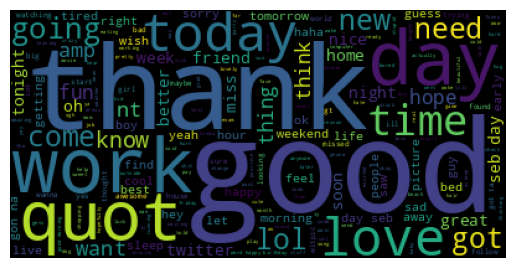

In [69]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

cloud=WordCloud()
cloud=cloud.generate(texts)

plt.imshow(cloud)
plt.axis("off")

# DETECTING LANG

In [72]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=d036a7eaf5d80b0404e51d43c9d1fca188e98f221eb9db97345e519bcff3039e
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [73]:
from langdetect import detect

In [74]:
detect("i love u")

'hr'

In [78]:
languages=[]
for text in x_train_cleaned:
  try:
    if(text!=''):
      lang=detect(text)
  except:
    lang='error'
    print('this error',text)
  languages.append(lang)

In [79]:
languages

['en',
 'en',
 'sl',
 'en',
 'en',
 'af',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'et',
 'en',
 'sl',
 'en',
 'en',
 'en',
 'en',
 'en',
 'no',
 'it',
 'so',
 'en',
 'en',
 'en',
 'sw',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'so',
 'ca',
 'en',
 'en',
 'tl',
 'en',
 'en',
 'af',
 'en',
 'tl',
 'es',
 'en',
 'sv',
 'en',
 'en',
 'en',
 'af',
 'en',
 'ca',
 'et',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'pl',
 'en',
 'sv',
 'so',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'af',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'it',
 'en',
 'en',
 'sw',
 'en',
 'id',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'it',
 'af',
 'en',
 'en',
 'en',
 'en',
 'no',
 'en',
 'da',
 'et',
 'pl',
 'en',
 'en',
 'en',
 'en',
 'it',
 'en',
 'af',
 'af',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'so',
 'en',
 'en',
 'tl',
 'en',
 'en',
 'en',
 'en',
 'en',